Phase 1: The Detective Work (Setup & Inspection)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data\customer_analytics.csv")
print(df.head())
print(df.info())
print(df.describe())

   CustomerID  Age  Gender    City Education MaritalStatus  AnnualIncome  \
0        1001   49    Male    Pune   Masters        Single       82953.0   
1        1002   31    Male    Pune       PhD        Single       52295.0   
2        1003   44    Male  Mumbai       NaN        Single       70444.0   
3        1004   23  Female  Mumbai   Masters       Married       46980.0   
4        1005   34    Male    Pune   Masters       Married       67195.0   

   SpendingScore  YearsEmployed  PurchaseFrequency  OnlineVisitsPerMonth  \
0             66             23                  7                    28   
1             43              4                  3                    24   
2             39             21                 10                    18   
3             56              1                  7                    20   
4             46             13                  2                    22   

   ReturnedItems PreferredDevice  LastPurchaseAmount  
0              2          Lapto

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\HARSHITH ALFRED\AppData\Local\Temp\ipykernel_3340\2621391258.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  df = pd.read_csv("data\customer_analytics.csv")


## Introduction
This dataset contains customer analytics data. Each row represents one individual customer and includes demographic information, income, employment, and purchasing behavior.

Phase 2: The Cleanup (Data Preprocessing)

In [3]:
print(df.isnull().sum())

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               25
MaritalStatus            0
AnnualIncome            26
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64


I filled missing AnnualIncome with the mean because it preserves the central tendency without discarding data. Missing Education values were replaced with 'Other' to maintain categorical consistency

In [5]:
df['AnnualIncome']=df['AnnualIncome'].fillna(df['AnnualIncome'].mean())
df['Education']=df['Education'].fillna('Other')

In [6]:
print(df.isnull().sum())

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64


In the AnnualIncome replaced the null with the means if the values
In teh Education replaced the null with Other values

Phase 3: The Deep Dive (Univariate & Bivariate Analysis)

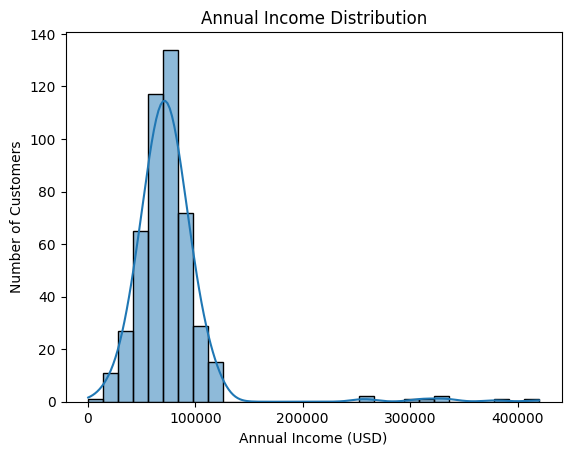

In [10]:
plt.figure()
sns.histplot(df['AnnualIncome'],kde=True,bins=30)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (USD)')
plt.ylabel('Number of Customers')
plt.show()

 Insight: Most customers earn a mid-range income (30k–70k USD). 
 Actionable: Offer mid-tier products and promotions targeting this majority group to maximize sales.

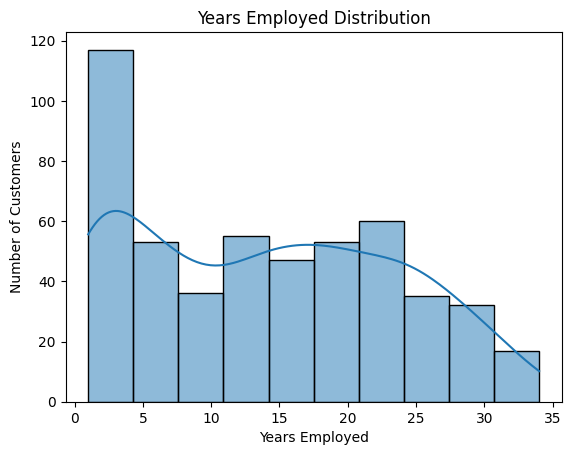

In [12]:
plt.figure()
sns.histplot(df['YearsEmployed'], kde=True)
plt.title('Years Employed Distribution')
plt.xlabel('Years Employed')
plt.ylabel('Number of Customers')
plt.show()

Insight: Most customers have 5–15 years of employment, indicating stability.
Actionable: Target loyalty programs to mid-career customers with stable income who are likely to spend consistently.

Annual Income was analyzed using a histogram, which showed a near bell-shaped distribution indicating most customers fall in the middle-income range.

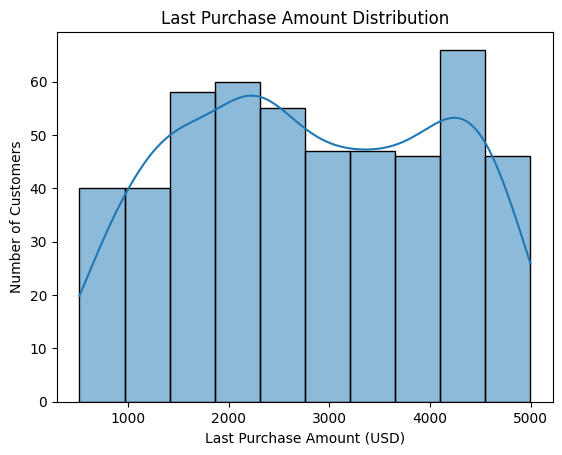

In [19]:
plt.figure()
sns.histplot(df['LastPurchaseAmount'],kde=True)
plt.title('Last Purchase Amount Distribution')
plt.xlabel('Last Purchase Amount (USD)')
plt.ylabel('Number of Customers')
plt.show()

 Insight: Purchase amounts are skewed; few customers make very high purchases.
 Actionable: Offer mid-tier incentives to the majority and VIP perks to high-spending customers to increase retention.

Last PurchaseAmount was analyzed using a histogram, which showed skewd distribution indicating most customers fall in 4000-45000

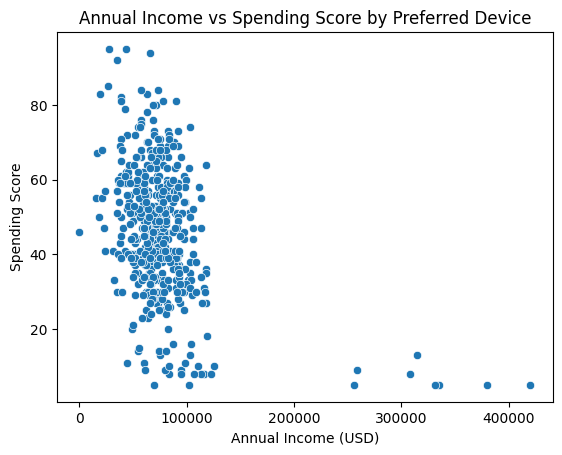

In [14]:
plt.figure()
plt.title('Annual Income vs Spending Score by Preferred Device')
plt.xlabel('Annual Income (USD)')
plt.ylabel('Spending Score')
sns.scatterplot(x='AnnualIncome',y='SpendingScore',data=df)
plt.show()

 Insight: Higher-income customers spend more conservatively. Device preference slightly affects spending.
 Actionable: Promote premium devices selectively to high-income customers who prefer them; for mid-income, offer bundled deals.


Spending Score was compared with income and device preference to analyze how earning level and device choice influence customer spending behavior.

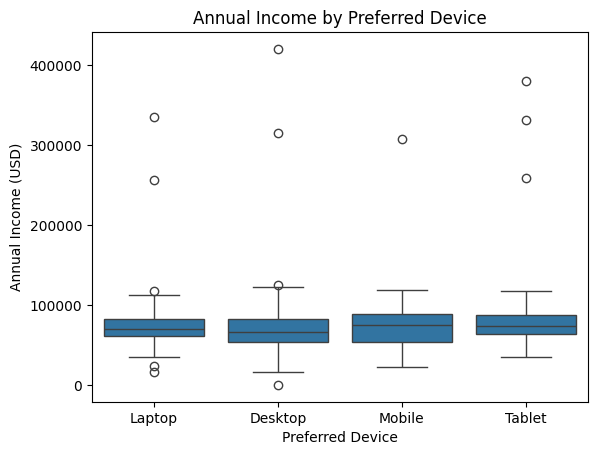

In [15]:
plt.figure()
plt.title('Annual Income by Preferred Device')
plt.xlabel('Preferred Device')
plt.ylabel('Annual Income (USD)')
sns.boxplot(y='AnnualIncome',x='PreferredDevice',data=df)
plt.show()

 Insight: Customers using premium devices tend to have higher income.
 Actionable: Use premium-device owners for targeted luxury marketing campaigns. Mid-income customers could be nudged toward mid-range devices with special offers.


Device preference was compared with annual income to understand which income group prefers which type of device.
This helped identify whether higher-income customers tend to choose premium devices.

Phase 4: The Big Picture (Multivariate & Storytelling)

In [17]:
corr = df.select_dtypes(include='number').corr()
print(corr)

                      CustomerID       Age  AnnualIncome  SpendingScore  \
CustomerID              1.000000 -0.015155     -0.018961       0.002378   
Age                    -0.015155  1.000000     -0.011624      -0.041309   
AnnualIncome           -0.018961 -0.011624      1.000000      -0.401847   
SpendingScore           0.002378 -0.041309     -0.401847       1.000000   
YearsEmployed          -0.016749  0.972852     -0.014175      -0.057578   
PurchaseFrequency       0.005190 -0.010245      0.052552      -0.057486   
OnlineVisitsPerMonth    0.062621  0.008214      0.093366      -0.002479   
ReturnedItems          -0.002815  0.019653     -0.015380       0.034159   
LastPurchaseAmount     -0.007824  0.017206      0.023778      -0.020542   

                      YearsEmployed  PurchaseFrequency  OnlineVisitsPerMonth  \
CustomerID                -0.016749           0.005190              0.062621   
Age                        0.972852          -0.010245              0.008214   
AnnualInc

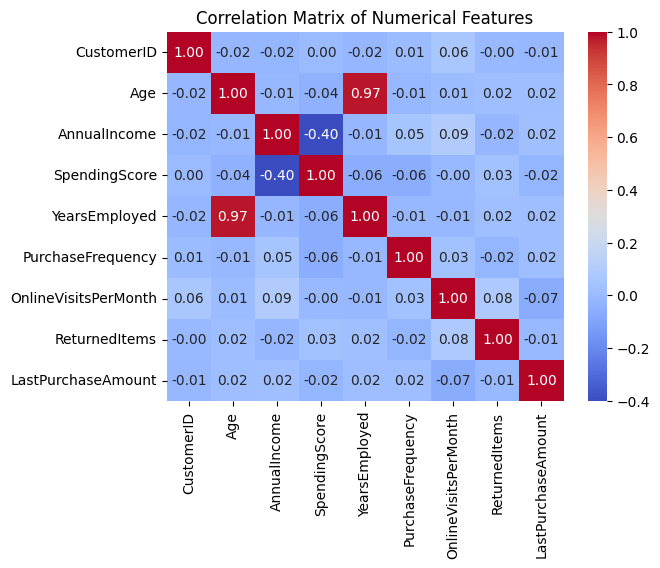

In [18]:
plt.figure()
sns.heatmap(data=corr,cmap='coolwarm',annot=True,fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

 Insight:
 - Age and YearsEmployed are highly correlated (0.97) → redundant for modeling.
 - Annual Income has moderate negative correlation with Spending Score (-0.39) → higher earners spend more conservatively.
 - Other features weakly correlated → multiple factors influence spending.